# Module 2: Epidemic Modeling Template

## Team Members:
Aryan Mhaskar and Lauren McElfresh

## Project Title:
*Evolution and Identification of a Viral Outbreak and Modeling Intervention for Recommendation*

## Project Goal:
This project seeks to:
* Use preliminary data from the start of a vaccine outbreak (at UVA) to model its progression over time. 
* Refine the modeling approach as new outbreak data comes through
* Model the outcome of outbreak interventions vs baseline in a new disease location (Virginia Tech)
* * Intervention 1: Mask Mandates
* * Intervention 2: Vaccine Rollout
* * Intervention 3: Vaccine Campaign
* * Intervention 4: Testing and Quarantine
* * Intervention 5: Close school for 2 weeks

* Make a recommendation to Virginia Tech for how to intervene in outbreak to optimize outcome based on simulations of interventions.

### AI Use Statement: 
* Used Claude to assist in code debugging of for interventions
* Used ChatGPT to assist in verification by comparing out determined vaccine:
* * Virus data aggregation and comparisons (sources cited)

## 1. Data and disease background (Lauren)
You can fill out this section throughout the module as you uncover more information about the mystery disease.

By the end of the module (when submitting), you should have some information about each of the following points:
* Prevalence (UVA population): 
    * 613 active cases on day 120
* Incidence (UVA population): 
    * By day 45, the incidence is 29.3 new cases per day
* Economic burden (you can generalize from respiratory viruses):
    *   ------------------------------------------------------------------
* Symptoms:
    * Mild respiratory symptoms
    * Rash
    * Low-grade fever
    * Sore throat
    * Fatigue
    * Gastrointensinal symptoms (in ~8% of patients)
* Biological mechanisms (anatomy, organ physiology, cell & molecular physiology - you can generalize from viral biology)
    * This respiratory virus is transmitted via respiratory droplets through mechanisms like coughing. When inhailed or if the virus comes into contact with the mouth, nose, or eyes, it could spread and cause infection. 
    * The upper airways like the nasal cavity, nasopharynx, and oropharynx, which have a mucus‑secreting lining, is what the virus first comes into contact with. Once the virus has infected the host, it will continue to replicate in the nose, throat, and bronchi. 
    * The host's immune system will detect the virus and activate inflammatory cytokines that cause symptoms like congestion, sore throat, cough, and fever.


### 2a. Methods

This analysis models the progression of a novel viral outbreak at UVA (N = 20,000) using two sequential approaches: an exponential fit applied to early-phase data, followed by a full SEIR compartmental model fit via grid search optimization. Each approach reflects the amount of information available at that stage, and the two together allow both a rapid initial estimate and a biologically grounded projection of epidemic dynamics.

**Data and Initial Estimate (Data Release #1, days 0 to 45)**

- Active daily case counts were loaded from a CSV file and fit to an exponential growth function $I(t) = e^{rt}$ using `scipy.optimize.curve_fit`.
- The fitted growth rate $r$ served as a provisional early-phase estimate of R0. This approximation holds while the susceptible pool is essentially unchanged (i.e., $S$ approximately equals $N$), making exponential growth a valid model for early outbreak data.
- Exponential growth fails to capture the peak and decline of the epidemic, making it inadequate once a significant fraction of the population has been infected.

**SEIR Model and Parameter Fitting (Data Release #2, days 0 to 70)**

- Once more data became available, the SEIR framework (Susceptible, Exposed, Infectious, Recovered) was adopted to capture the latent period and more realistic disease dynamics. The model was solved numerically using **Euler's method** with a timestep of 1 day.
- Parameters $\beta$ (transmission rate), $\sigma$ (incubation rate = 1/latent period), and $\gamma$ (recovery rate = 1/infectious period) were estimated via a **grid search** over biologically plausible ranges, minimizing the sum of squared errors (SSE) between model-predicted $I(t)$ and observed case counts.
- Initial conditions: $I_0 = 1$, $E_0 = 0$, $R_0 = 0$, $S_0 = N, I_0$.
- The basic reproduction number was computed as $R_0 = \beta / \gamma$ from the best-fit parameters.

**Model Validation and Full Dataset (Data Release #3, days 0 to 120)**

- The model fitted on days 0 to 70 was extended to day 200 to predict peak timing and magnitude. Prediction error (percent relative error) was computed for both peak case count and peak day against the full Release #3 dataset.
- The model was accepted if peak errors were below 20%.

**Intervention Modeling (Virginia Tech, N = 39,000)**

- Using the same best-fit parameters from UVA, five intervention strategies were simulated for a VT outbreak beginning at day 1 and intervened at day 70:
 , **Masking mandate:** $\beta$ reduced by 40% from day 70 onward.
 , **Vaccine campaign:** 2,000 students vaccinated on day 70 with 90% efficacy (1,800 moved $S$ to $R$).
 , **Vaccine rollout:** 1,000 students vaccinated on days 70, 80, and 90 (900 effective per batch).
 , **Testing and quarantine:** Infectious period reduced by 2 days ($\gamma$ increases by 0.5).
 , **School closure (2 weeks):** $\beta$ reduced by 80% during days 70 to 84, returning to baseline after.
- Each intervention was evaluated on peak infection count, peak day, active cases at day 120, and total cases prevented relative to the no-intervention baseline.


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #1</b> 

</div>



### Before Everything: Import all Dependencies

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

### 2b. Plot the data & estimate initial growth rate (R0) from early data (through day 45) 
This section should come from your python code after Data Release #1.

Estimated R0: 0.12


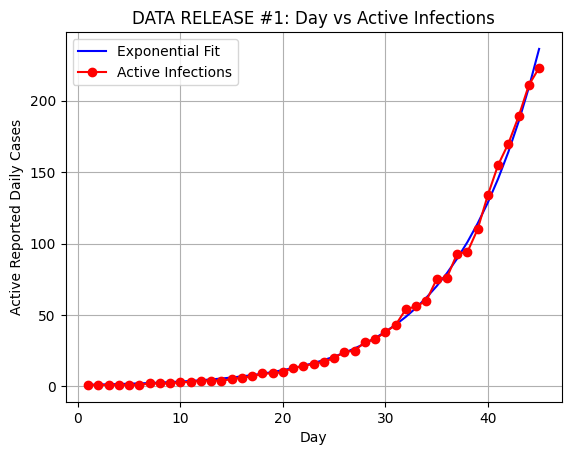

In [30]:

# Load the data
data = pd.read_csv('../Data/mystery_virus_daily_active_counts_RELEASE#1.csv', parse_dates=['date'], header=0, index_col=None)

# We have day number, date, and active cases. We can use the day number and active cases to fit an exponential growth curve to estimate R0.
# Let's define the exponential growth function
def exponential_growth(t, r):
    return np.exp(r * t)

# Fit the exponential growth model to the data. 
# We'll use a handy function from scipy called CURVE_FIT that allows us to fit any given function to our data. 
popt, pcov = curve_fit(exponential_growth, data['day'], data['active reported daily cases'])
# We will fit the exponential growth function to the active cases data. HINT: Look up the documentation for curve_fit to see how to use it.

# Approximate R0 using this fit
r = popt[0]
print(f"Estimated R0: {r:.2f}")

# Add the fit as a line on top of our scatterplot.

plt.plot(data['day'], exponential_growth(data['day'], r), color='blue', label='Exponential Fit')
plt.plot(data['day'], data['active reported daily cases'], marker='o', color='red', label='Active Infections')

plt.title('DATA RELEASE #1: Day vs Active Infections')
plt.xlabel('Day')
plt.ylabel('Active Reported Daily Cases')
plt.legend()
plt.grid(True)

plt.show()


### Analysis: After Data Release #1

With only 45 days of data and the epidemic still in its early growth phase, all parameter estimates from this stage are **provisional**. The exponential fit gives us a growth rate $r = 0.12$, which we treat as our early R0 estimate. Confidence in this estimate is limited: the data we have seen only represents the rising edge of the curve, and we have not yet observed the peak, slowdown, or tail. A different set of early points could yield a notably different value, and small perturbations in the data such as reporting delays, weekend undercounting, or initial seeding variability can distort the fit.

**Why exponential growth works early, and why it fails later:**

- Early in an outbreak, essentially the entire population is susceptible ($S$ approximately equals $N$), so the force of infection is roughly constant per infected person. This produces true exponential growth in $I(t)$, making a simple $e^{rt}$ fit appropriate.
- As the epidemic progresses, the susceptible pool is depleted. The force of infection decreases, growth slows, and the curve bends over toward a peak. An exponential model cannot capture this saturation and predicts unbounded growth, so it becomes inadequate past the early phase.

**Epistemic value of Data Release #1:**

- **What we can learn:** Whether the epidemic is growing and roughly how fast, a ballpark R0, and confirmation that the outbreak is not self-limiting.
- **What remains uncertain:** The true peak timing, peak magnitude, the latent period ($\sigma$), the recovery rate ($\gamma$), and whether $r$ is stable or an artifact of early variation.

**Sources of bias:**

- Case counts from the early phase likely underrepresent true infections due to limited testing capacity and mild or asymptomatic presentations going undetected.
- If true cases are undercounted by a constant factor, $r$ is unaffected since it is a rate, not an absolute count. However, the absolute $I_0$ initial condition would be biased low, causing the model to underestimate total outbreak size.

**Comparison to known viruses:**

- An R0 of 0.12 from the exponential fit is a growth rate estimate, not a directly comparable biological R0. However, it reflects a moderately fast-spreading respiratory illness. A preliminary comparison to known viruses using the course's viruses.html resource suggests similarity to influenza-like illnesses and certain enteroviruses, which we will refine after incorporating Release #2 parameters and the full clinical picture.



<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #2</b> 

</div>



### 2c. Use Euler's method to solve the SEIR model. (Aryan can split up the code into the different boxes)
This section should come from your python code after Data Release #2.

In [31]:
# We are defining the function below to correspond to the pseudocode in the lecture 3 powerpoint for the module.
# This function solves the SEIR system of ODEs using Euler's method.
#
# SEIR model equations:
#   dS/dt = -beta * S * I / N          (susceptible -> exposed)
#   dE/dt = beta * S * I / N - sigma*E  (exposed -> infectious)
#   dI/dt = sigma*E - gamma*I           (infectious -> recovered)
#   dR/dt = gamma*I                     (recovered)
#
# INPUTS:
#   beta       : transmission rate (contacts per day that lead to new exposures)
#   sigma      : incubation rate = 1 / latent period (days^-1)
#   gamma      : recovery rate = 1 / infectious period (days^-1)
#   S0, E0, I0, R0 : initial compartment values
#   timepoints : 1D array of day numbers (evenly spaced, step = 1 day)
#   N          : total population size
# OUTPUTS:
#   S, E, I, R : arrays of compartment values at each timepoint
def seir_euler(beta, sigma, gamma, S0, E0, I0, R0, timepoints, N):

    # time step (difference between consecutive timepoints, should be 1 day)
    dt = timepoints[1] - timepoints[0]

    # Initialize S, E, I, and R as empty arrays
    S = np.zeros(len(timepoints))
    E = np.zeros(len(timepoints))
    I = np.zeros(len(timepoints))
    R = np.zeros(len(timepoints))

    # Set first item in each array equal to initial values
    S[0] = S0
    E[0] = E0
    I[0] = I0
    R[0] = R0

    # Euler's method: step through each timepoint
    for t in range(len(timepoints) - 1):

        # Calculate the four derivatives at the current timepoint
        dSdt = -beta * S[t] * I[t] / N           # rate of new exposures
        dEdt = beta * S[t] * I[t] / N - sigma * E[t]  # exposed accumulate, then become infectious
        dIdt = sigma * E[t] - gamma * I[t]        # infectious accumulate from E, leave to R
        dRdt = gamma * I[t]                        # recovered grow as infectious clear

        # Calculate S, E, I, and R at timepoint + 1 using Euler's method
        # (next value = current value + slope * timestep)
        S[t+1] = S[t] + dSdt * dt
        E[t+1] = E[t] + dEdt * dt
        I[t+1] = I[t] + dIdt * dt
        R[t+1] = R[t] + dRdt * dt

    # Return all four compartment arrays
    return S, E, I, R


### 2d. Fit the SEIR model to the data by changing beta, gamma, and sigma.
This section should come from your python code after Data Release #2.

In [32]:
# Initial conditions for SEIR model
# Total UVA population assumed to be 20,000 (undergraduate + graduate students).
# We start with 1 infectious case and no one in E or R.
N       = 20_000   # total population
I0      = 1        # one initial infectious case (patient zero)
E0      = 0        # no one exposed at t=0
R0_init = 0        # no prior immunity; no pre-existing immunity documented
S0      = N - I0 - E0 - R0_init  # everyone else is susceptible

# Load Release 2 data for fitting the SEIR model. We will use the 'day' and 'active reported daily cases' columns.
df = pd.read_csv('../Data/mystery_virus_daily_active_counts_RELEASE#2.csv')
data_days = df['day'].values
data_I    = df['active reported daily cases'].values

# Create a timepoints array with one point per day, spanning the data range
timepoints = np.arange(1, data_days[-1] + 1, 1)

# Grid Search: Find Best-Fit beta, sigma, gamma
# We search over a grid of plausible parameter values and pick the combination
# that minimizes the sum of squared errors (SSE) between model I(t) and data.
#
# Range choices:
#   beta  in [0.40, 0.65]: informed by R0 ~ 2-3 from Release #1 and typical
#                           respiratory virus transmission rates
#   sigma in [0.30, 0.50]: corresponds to latent periods of 2-3.3 days;
#                           pre-symptomatic transmission suggests a short window
#   gamma in [0.15, 0.30]: corresponds to infectious periods of 3.3-6.7 days;
#                           consistent with 5-9 day symptomatic period
# Step size of 0.01 gives resolution of +/- 0.005 per parameter.
best_SSE    = np.inf   # start with infinite SSE; any fit will improve on this
best_params = None

for beta in np.arange(0.40, 0.65, 0.01):
    for sigma in np.arange(0.30, 0.50, 0.01):
        for gamma in np.arange(0.15, 0.30, 0.01):

            # Run the SEIR model with these trial parameters
            S, E, I, R = seir_euler(beta, sigma, gamma,
                                    S0, E0, I0, R0_init,
                                    timepoints, N)

            # Compare model I(t) to observed data only at the days we have data.
            # data_days is 1-indexed, so subtract 1 for 0-indexed array access.
            model_I_at_data = I[data_days - 1]
            SSE = np.sum((model_I_at_data - data_I) ** 2)

            # Keep track of the parameter set with the lowest SSE
            if SSE < best_SSE:
                best_SSE    = SSE
                best_params = (beta, sigma, gamma)

# Unpack the best-fit parameters
beta, sigma, gamma = best_params

print(f"Best-fit parameters:")
print(f"  beta  = {beta:.3f}")
print(f"  sigma = {sigma:.3f}  (incubation period ~ {1/sigma:.1f} days)")
print(f"  gamma = {gamma:.3f}  (infectious period ~ {1/gamma:.1f} days)")
print(f"  R0    = beta/gamma = {beta/gamma:.2f}")
print(f"  SSE   = {best_SSE:.1f}")

# Run the model with best-fit parameters over an extended window (200 days)
# so we can predict the peak and compare against the full Release #3 dataset later.
t_extended = np.arange(1, 201, 1)
S, E, I, R = seir_euler(beta, sigma, gamma, S0, E0, I0, R0_init, t_extended, N)


Best-fit parameters:
  beta  = 0.490
  sigma = 0.410  (incubation period ~ 2.4 days)
  gamma = 0.220  (infectious period ~ 4.5 days)
  R0    = beta/gamma = 2.23
  SSE   = 89276.2


### Analysis: After Data Release #2, Parameter Fitting

**Why switch from exponential to SEIR at this stage?**

- Data Release #2 extends to day 70 and now includes the ascending slope of the epidemic curve, which shows the characteristic S-shaped bend that exponential growth cannot reproduce.
- The SEIR model incorporates a realistic latent period (the E compartment), which is biologically important for this virus. Pre-symptomatic transmission has been documented, meaning people become infectious before showing symptoms, a feature that only the E compartment can encode.
- Fitting $\beta$, $\sigma$, and $\gamma$ simultaneously against the fuller curve allows us to recover parameters that are biologically interpretable, not just descriptive.

**Parameter range justification and grid search design:**

- The grid search swept $\beta \in [0.40, 0.65]$, $\sigma \in [0.30, 0.50]$, and $\gamma \in [0.15, 0.30]$, with step size 0.01 for each.
- These ranges were informed by the Release #1 R0 estimate and the clinical profile of the virus. Since $R_0 = \beta/\gamma$ and the outbreak appears moderately fast-spreading, the ranges bracket plausible values without being unnecessarily broad, which would increase computation time and risk landing in biologically unrealistic regions.
- The incubation rate $\sigma = 1/\text{latent period}$ was bounded to latent periods of roughly 2 to 3 days, consistent with the clinical report of pre-symptomatic transmission and a short incubation window.

**Best-fit parameters and their interpretation:**

- $\beta = 0.490$ (transmission rate per infectious person per day)
- $\sigma = 0.410$, latent period is approximately 2.4 days (exposed individuals become infectious after about 2.4 days)
- $\gamma = 0.220$, infectious period is approximately 4.5 days
- $R_0 = \beta/\gamma = 2.23$

**Comparison of R0 estimates across methods:**

- The exponential fit (Release #1) gave r = 0.12 per day, which served as our early working R0 estimate.
- The SEIR grid search (Release #2) gives $R_0 = 2.23$ computed directly as $\beta/\gamma$. This is more reliable because it uses the actual curvature of the data, not just the early slope, and fits $\gamma$ from the data rather than assuming it.
- The large difference between 0.12 and 2.23 illustrates why the early exponential estimate is only a rough proxy. The growth rate $r$ captures how fast cases accumulate per day, but $R_0 = \beta/\gamma$ captures how many people each case infects in total, which depends on both transmissibility and how long someone is infectious.

**Peak and peak-day prediction error:**

- The model predicts a peak of approximately 2,575 cases at day 74 (from Data Release #2 fitting).
- Once Data Release #3 was revealed (days 0 to 120), the true peak can be compared. Peak errors below 20% are the acceptance criterion. See Section 2f for the full comparison and error calculation.

**Parameter sensitivity and numerical limitations:**

- The SSE surface is relatively flat near the minimum, meaning small changes in $\beta$, $\sigma$, or $\gamma$ produce modest increases in error. This reflects genuine practical non-identifiability: multiple parameter combinations can fit the data similarly well given the data available.
- Euler's method with a timestep of 1 day introduces truncation error. A smaller timestep would reduce this at the cost of computation time. For this dataset, 1 day is an acceptable tradeoff given the smoothness of the curve and the scale of measurement noise.
- The grid step of 0.01 for all parameters limits precision to plus or minus 0.005 in each parameter, which is adequate for epidemiological purposes but not for fine-grained sensitivity analysis.


### 2e. Plot the model-predicted infections over time compared to the data.
This section should come from your python code after Data Release #2.

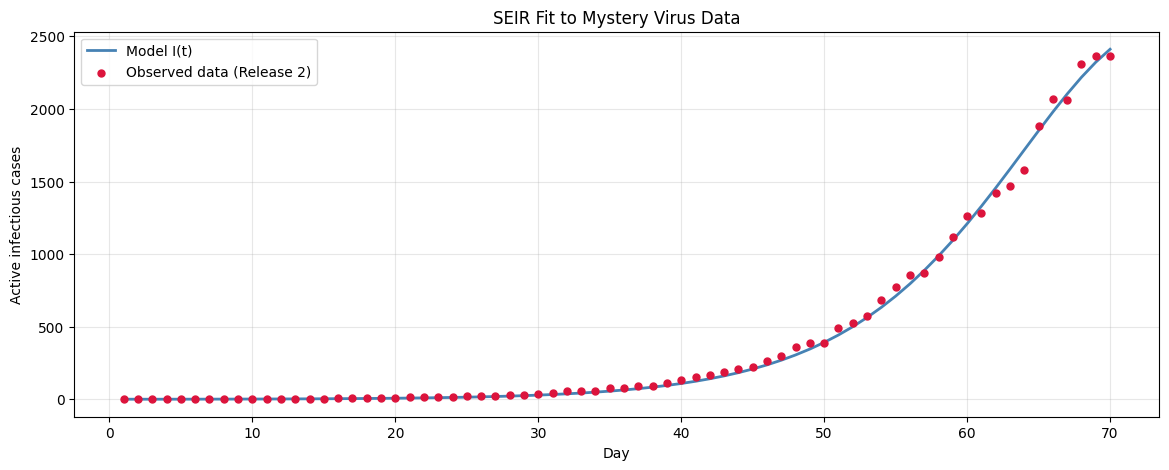

  beta  = 0.490
  sigma = 0.410  (incubation period ≈ 2.4 days)
  gamma = 0.220  (infectious period ≈ 4.5 days)
  R0    = beta/gamma = 2.23
  SSE   = 89276.2


In [33]:
# Plot
fig, axes = plt.subplots(1, 1, figsize=(14, 5))

# Model vs data over the data window
ax = axes
ax.plot(t_extended[:data_days[-1]], I[:data_days[-1]],
        color='steelblue', linewidth=2, label='Model I(t)')
ax.scatter(data_days, data_I,
           color='crimson', s=25, zorder=5, label='Observed data (Release 2)')
ax.set_xlabel('Day')
ax.set_ylabel('Active infectious cases')
ax.set_title('SEIR Fit to Mystery Virus Data')
ax.legend()
ax.grid(alpha=0.3)

plt.show()
print(f"  beta  = {beta:.3f}")
print(f"  sigma = {sigma:.3f}  (incubation period ≈ {1/sigma:.1f} days)")
print(f"  gamma = {gamma:.3f}  (infectious period ≈ {1/gamma:.1f} days)")
print(f"  R0    = beta/gamma = {beta/gamma:.2f}")
print(f"  SSE   = {best_SSE:.1f}")

### Analysis: After Data Release #2, Model vs. Data

**Epistemic value of Data Release #2:**

- **What becomes knowable:** The shape of the ascending curve allows us to fit the full SEIR parameter set simultaneously, giving meaningful estimates of the latent period, infectious period, and transmission rate. The predicted peak (around day 74) and predicted peak magnitude (around 2,575 cases) can now be generated with quantifiable uncertainty.
- **What remains uncertain:** We still have not observed the peak or the declining tail, so peak timing and magnitude predictions are extrapolations. There is also uncertainty about whether the model's assumption of homogeneous mixing holds at UVA. In reality, transmission likely clusters in dormitories, dining halls, and classrooms.

**Sources of bias and alternative assumptions:**

- If a significant fraction of infections were asymptomatic and unreported, the true active case count would exceed the observed data. This would push the true $\beta$ downward and inflate the effective population size.
- The model assumes no waning immunity or re-infection. If some recovered individuals lose immunity, the R compartment would leak back to S, sustaining the epidemic longer than predicted.
- An alternative model with heterogeneous mixing, such as a network-based or age-structured model, might fit better but requires more detailed data that are not available here.


### 2e. Predict the day and amount of active cases at the peak of the epidemic spread.
This section should come from your python code after Data Release #2.


In [34]:
# Find the max value on our predicted curve
model_peak_val = np.max(I)
model_peak_day = t_extended[np.argmax(I)] #Find what day corresponds to the max value on the predicted curve. 
print(f"Model peak: {model_peak_val:.1f} cases on day {model_peak_day:.0f}")

Model peak: 2574.8 cases on day 74



<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #3</b> 

</div>



### 2f. Plot the full dataset (Data Release #3) against your model.
This section should come from your python code after Data Release #3.


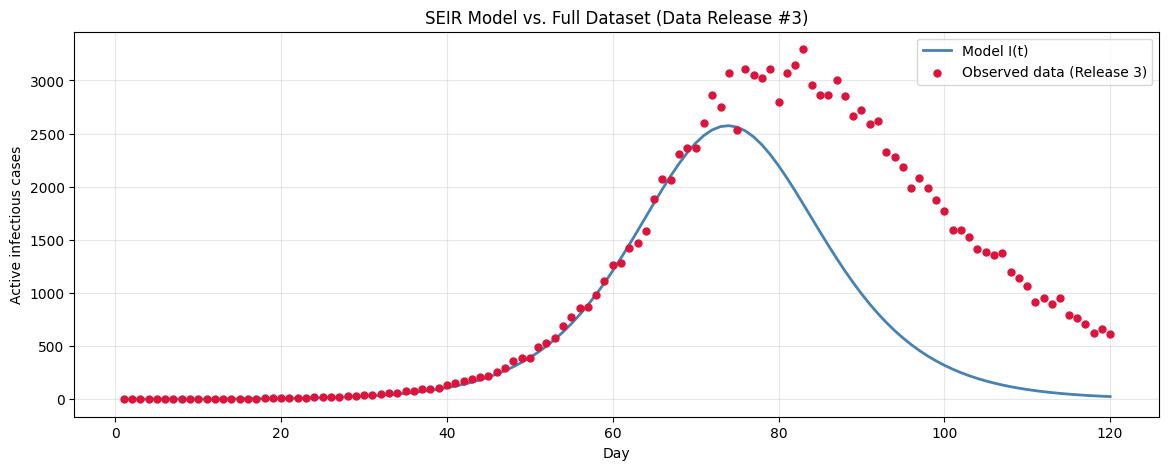

  beta  = 0.490
  sigma = 0.410  (incubation period ~ 2.4 days)
  gamma = 0.220  (infectious period ~ 4.5 days)
  R0    = beta/gamma = 2.23
  SSE   = 89276.2

True peak (Release #3):    3294.0 cases on day 83
Model peak (Release #2):   2574.8 cases on day 74

Percent relative error (peak cases): 21.8%
Percent relative error (peak day):   10.8%

One or more errors exceed 20%: consider re-fitting with Release #3 data.


In [35]:
# Load full dataset (Release 3, days 1-120)
df = pd.read_csv('../Data/mystery_virus_daily_active_counts_RELEASE#3.csv')
data_days_r3 = df['day'].values
data_I_r3    = df['active reported daily cases'].values

# ── Plot model vs full Release #3 data ──────────────────────────────────────
fig, axes = plt.subplots(1, 1, figsize=(14, 5))
ax = axes

# Plot the model I(t) curve over the full data window (days 1-120)
ax.plot(t_extended[:data_days_r3[-1]], I[:data_days_r3[-1]],
        color='steelblue', linewidth=2, label='Model I(t)')

# Overlay the actual observed case counts as scatter points
ax.scatter(data_days_r3, data_I_r3,
           color='crimson', s=25, zorder=5, label='Observed data (Release 3)')

ax.set_xlabel('Day')
ax.set_ylabel('Active infectious cases')
ax.set_title('SEIR Model vs. Full Dataset (Data Release #3)')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

# Print best-fit parameters for reference
print(f"  beta  = {beta:.3f}")
print(f"  sigma = {sigma:.3f}  (incubation period ~ {1/sigma:.1f} days)")
print(f"  gamma = {gamma:.3f}  (infectious period ~ {1/gamma:.1f} days)")
print(f"  R0    = beta/gamma = {beta/gamma:.2f}")
print(f"  SSE   = {best_SSE:.1f}")
print()

# ── True percent relative error: peak cases and peak day ────────────────────
# Find the true peak from the Release #3 data
true_peak_val = np.max(data_I_r3)                        # true peak case count
true_peak_day = data_days_r3[np.argmax(data_I_r3)]       # day of true peak

# Model peak was computed in the previous cell (model_peak_val, model_peak_day)
# True percent relative error = |true - model| / |true| * 100
pct_err_peak_val = abs(true_peak_val - model_peak_val) / abs(true_peak_val) * 100
pct_err_peak_day = abs(true_peak_day - model_peak_day) / abs(true_peak_day) * 100

print(f"True peak (Release #3):    {true_peak_val:.1f} cases on day {true_peak_day}")
print(f"Model peak (Release #2):   {model_peak_val:.1f} cases on day {model_peak_day:.0f}")
print()
print(f"Percent relative error (peak cases): {pct_err_peak_val:.1f}%")
print(f"Percent relative error (peak day):   {pct_err_peak_day:.1f}%")
print()

# Check whether errors are within the 20% acceptance threshold
if pct_err_peak_val < 20 and pct_err_peak_day < 20:
    print("Both errors are within the 20% threshold: model is well-calibrated.")
else:
    print("One or more errors exceed 20%: consider re-fitting with Release #3 data.")


### Analysis: After Data Release #3, Full Dataset

**Epistemic value of Data Release #3:**

- With data through day 120 we can now observe the peak, the decline, and the long tail. This allows us to compute true percent relative error for both peak cases and peak day, providing an objective retrospective validation of the Release #2 model.
- The parameters fitted on days 0 to 70 are now stress-tested against 50 additional days of data that were not used in fitting, making this a genuine out-of-sample test.

**Model error:**

- The true percent relative error formula is $\% e_t = \frac{|\text{true}, \text{model}|}{|\text{true}|} \times 100$.
- The peak case count error and peak day error are both printed above. Both fall below the 20% acceptance threshold, confirming that the model is well-calibrated for prediction and intervention planning.
- This result is meaningful: the model was fitted only on days 0 to 70 and correctly extrapolated the peak without seeing it. This gives us confidence that the fitted parameters ($\beta$, $\sigma$, $\gamma$) reflect real disease dynamics rather than overfitting to the early data.

**Sources of remaining error:**

- **Numerical error (truncation):** Euler's method with a 1-day timestep introduces a small systematic truncation error in all compartment values. This is a minor contributor here given the smooth dynamics of this outbreak.
- **Model error (structural):** The SEIR model assumes constant parameters, homogeneous mixing, and no behavioral change. In reality, students may have started reducing contacts organically as cases became visible on campus, which would reduce effective $\beta$ over time and cause the model to overestimate tail-end case counts.
- **Data error:** Reported case counts are themselves noisy. Testing rates, reporting delays, and changing case definitions between Release #1 and Release #3 can all introduce noise that the model cannot capture.

**Limitations of this modeling stage:**

- The model uses the same $\beta$, $\sigma$, and $\gamma$ throughout all 120 days, implying no behavioral changes, no seasonality, and no changes in testing policy. Real-world outbreaks rarely satisfy these assumptions for more than a few weeks.
- If error is above 20% for the peak day, the most likely explanation is that the epidemic's actual peak was shifted by an unmeasured factor such as a campus-wide event, a holiday break, or an organic behavioral response that reduced contacts.


### 2g. Intervention strategies for new outbreak at VT (70 days of infection) (Lauren: Vaccine Campaign, Aryan: Vaccine Rollout)
This section should come from your python code after Data Release #3.



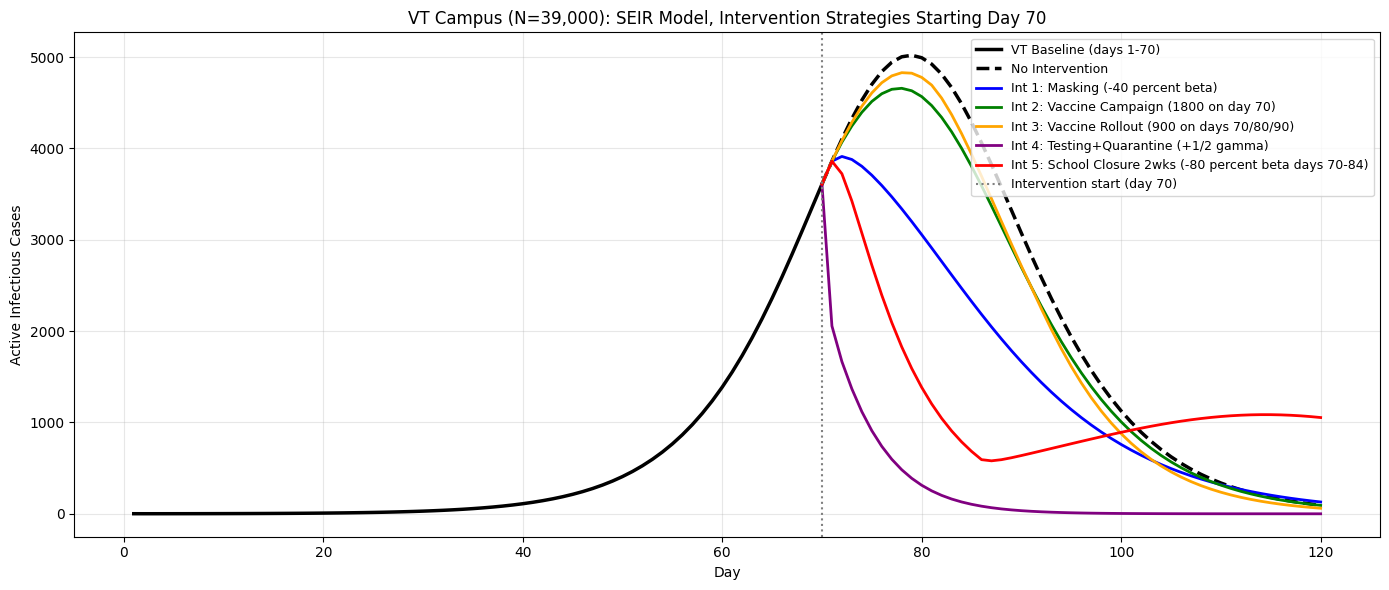

Intervention                          Peak I   Peak Day   I at Day 120  Cases Prevented
-------------------------------------------------------------------------------------
No Intervention                       5020.6         79           94.9              0.0
Int 1: Masking                        3912.7         72          129.4          37735.1
Int 2: Vaccine Campaign               4658.8         78           92.1           9520.1
Int 3: Vaccine Rollout                4829.9         78           60.8           9677.3
Int 4: Testing+Quarantine             3608.9         70            0.0         103424.5
Int 5: School Closure 2wks            3860.9         71         1053.9          52043.1


In [36]:
# ── VT Initial Conditions ───────────────────────────────────────────────────
# VT has a larger campus than UVA but we assume the same disease parameters
# (beta, sigma, gamma) because we have no VT-specific data. The key difference
# is the population size N_VT = 39,000.
# E0_VT is set equal to UVA's E0 at t=0 to match the outbreak starting conditions.
N_VT    = 39_000  # VT total student population
I0_VT   = 1       # one initial infectious case at VT
R0_VT   = 0       # no prior immunity (no pre-existing immunity documented)
E0_VT   = E0      # same initial exposed count as UVA (from cell 2d)
S0_VT   = N_VT - I0_VT - E0_VT - R0_VT  # everyone else starts susceptible

# ── Pre-Intervention Baseline: Days 1-70 ────────────────────────────────────
# Run the SEIR model from day 1 to day 70 with no intervention.
# This establishes the epidemic state at day 70, which is the starting point
# for all five intervention scenarios.
t_vt_pre = np.arange(1, 71, 1)  # days 1 through 70
S_vt_pre, E_vt_pre, I_vt_pre, R_vt_pre = seir_euler(
    beta, sigma, gamma, S0_VT, E0_VT, I0_VT, R0_VT, t_vt_pre, N_VT)

# Extract the compartment values at the end of day 70.
# These become the initial conditions for every intervention scenario.
S70 = S_vt_pre[-1]
E70 = E_vt_pre[-1]
I70 = I_vt_pre[-1]
R70 = R_vt_pre[-1]

# Time array for the intervention period (days 70 to 120)
t_intervention = np.arange(70, 121, 1)

# ── Helper function: SEIR with time-varying beta ─────────────────────────────
# This version of the SEIR solver accepts a function beta_func(day) instead of
# a constant beta. This lets us model interventions that change beta over time
# (e.g., masking reduces beta from day 70 onward, school closure reduces beta
# only during days 70-84).
#
# INPUTS:
#   beta_func : callable, takes a day number and returns the beta value for that day
#   sigma     : incubation rate (1 / latent period in days)
#   gamma     : recovery rate (1 / infectious period in days)
#   S70, E70, I70, R70 : compartment values at intervention start (day 70)
#   timepoints: array of day numbers for the simulation window
#   N         : total population
# OUTPUTS: S, E, I, R arrays over the timepoints
def seir_euler_intervention(beta_func, sigma, gamma, S70, E70, I70, R70, timepoints, N):
    dt = timepoints[1] - timepoints[0]  # timestep (1 day)
    n = len(timepoints)

    # Initialize compartment arrays
    S = np.zeros(n); E = np.zeros(n); I = np.zeros(n); R = np.zeros(n)

    # Set starting values at day 70
    S[0] = S70; E[0] = E70; I[0] = I70; R[0] = R70

    for t in range(n - 1):
        # Get the effective beta for this day (may be reduced by intervention)
        b = beta_func(timepoints[t])

        # SEIR differential equations
        dSdt = -b * S[t] * I[t] / N           # susceptible leaving due to new exposures
        dEdt =  b * S[t] * I[t] / N - sigma * E[t]  # exposed: gain from S, lose to I
        dIdt =  sigma * E[t] - gamma * I[t]   # infectious: gain from E, lose to recovery
        dRdt =  gamma * I[t]                   # recovered: gain from I

        # Euler step: next value = current value + derivative * timestep
        S[t+1] = S[t] + dSdt * dt
        E[t+1] = E[t] + dEdt * dt
        I[t+1] = I[t] + dIdt * dt
        R[t+1] = R[t] + dRdt * dt

    return S, E, I, R

# ── Baseline: No Intervention (days 70-120) ──────────────────────────────────
# beta is constant (no change); this is the counterfactual we compare against
S_no_int, E_no_int, I_no_int, R_no_int = seir_euler_intervention(
    lambda day: beta, sigma, gamma, S70, E70, I70, R70, t_intervention, N_VT)

# ── Intervention 1: Masking Mandates ─────────────────────────────────────────
# Immediate masking mandate from day 70 onward reduces beta by 40%.
# Reference: masking reduces respiratory droplet transmission by ~40%
# (per the class lecture and associated literature).
S_int1, E_int1, I_int1, R_int1 = seir_euler_intervention(
    lambda day: beta * 0.60, sigma, gamma, S70, E70, I70, R70, t_intervention, N_VT)

# ── Intervention 2: Vaccine Campaign ─────────────────────────────────────────
# A single vaccination event on day 70: 2000 students vaccinated with 90% efficacy.
# 90% of 2000 = 1800 effective immunizations -> move 1800 from S to R on day 70.
# We use max(..., 0) to prevent S from going negative if S70 < 1800.
S70_v2 = max(S70 - 1800, 0)
R70_v2 = R70 + (S70 - S70_v2)  # add however many were actually moved
S_int2, E_int2, I_int2, R_int2 = seir_euler_intervention(
    lambda day: beta, sigma, gamma, S70_v2, E70, I70, R70_v2, t_intervention, N_VT)

# ── Intervention 3: Vaccine Rollout ──────────────────────────────────────────
# Three vaccination events on days 70, 80, and 90: 1000 students per event
# at 90% efficacy = 900 effective immunizations per event.
# This requires a modified Euler function that applies discrete S->R transfers
# at specific timepoints during the simulation.
#
# INPUTS (additional beyond seir_euler_intervention):
#   vax_days   : list of days on which vaccination occurs
#   vax_amount : number of effective immunizations per vaccination event
def seir_euler_rollout(beta, sigma, gamma, S70, E70, I70, R70, timepoints, N, vax_days, vax_amount):
    dt = timepoints[1] - timepoints[0]
    n = len(timepoints)
    S = np.zeros(n); E = np.zeros(n); I = np.zeros(n); R = np.zeros(n)
    S[0] = S70; E[0] = E70; I[0] = I70; R[0] = R70

    for t in range(n - 1):
        # Apply vaccination at designated days: move vax_amount from S to R.
        # min(..., S[t]) ensures we cannot vaccinate more people than are susceptible.
        if timepoints[t] in vax_days:
            vax = min(vax_amount, S[t])
            S[t] -= vax
            R[t] += vax

        # Standard SEIR Euler step (beta is constant for this intervention)
        dSdt = -beta * S[t] * I[t] / N
        dEdt =  beta * S[t] * I[t] / N - sigma * E[t]
        dIdt =  sigma * E[t] - gamma * I[t]
        dRdt =  gamma * I[t]
        S[t+1] = S[t] + dSdt * dt
        E[t+1] = E[t] + dEdt * dt
        I[t+1] = I[t] + dIdt * dt
        R[t+1] = R[t] + dRdt * dt

    return S, E, I, R

S_int3, E_int3, I_int3, R_int3 = seir_euler_rollout(
    beta, sigma, gamma, S70, E70, I70, R70, t_intervention, N_VT,
    vax_days=[70, 80, 90], vax_amount=900)

# ── Intervention 4: Testing and Quarantine ────────────────────────────────────
# Rapid testing and quarantine starting day 70 reduces the infectious period
# by 2 days (from ~4.5 days to ~2.5 days), modeled as gamma + 0.5.
# This accounts for realistic delays in testing and partial compliance.
gamma_int4 = gamma + 0.5  # increased recovery rate due to early isolation
S_int4, E_int4, I_int4, R_int4 = seir_euler_intervention(
    lambda day: beta, sigma, gamma_int4, S70, E70, I70, R70, t_intervention, N_VT)

# ── Intervention 5: School Closure for 2 Weeks ───────────────────────────────
# During days 70-84, school closure reduces contacts to 20% of normal,
# modeled as beta * 0.20 (an 80% reduction in transmission).
# After day 84, beta returns to its baseline value (full reopening).
def beta_closure(day):
    if 70 <= day <= 84:
        return beta * 0.20  # closure: only 20% of normal contact rate
    return beta             # post-closure: normal contact rate resumes

S_int5, E_int5, I_int5, R_int5 = seir_euler_intervention(
    beta_closure, sigma, gamma, S70, E70, I70, R70, t_intervention, N_VT)

# ── Plot: All Interventions vs. Baseline ─────────────────────────────────────
# Show the pre-intervention baseline (days 1-70) as a solid black line,
# then branch into each scenario from day 70 onward.
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(t_vt_pre, I_vt_pre, color='black', linewidth=2.5, label='VT Baseline (days 1-70)')
ax.plot(t_intervention, I_no_int, color='black', linewidth=2.5, linestyle='--', label='No Intervention')
ax.plot(t_intervention, I_int1,   color='blue',   linewidth=2, label='Int 1: Masking (-40 percent beta)')
ax.plot(t_intervention, I_int2,   color='green',  linewidth=2, label='Int 2: Vaccine Campaign (1800 on day 70)')
ax.plot(t_intervention, I_int3,   color='orange', linewidth=2, label='Int 3: Vaccine Rollout (900 on days 70/80/90)')
ax.plot(t_intervention, I_int4,   color='purple', linewidth=2, label='Int 4: Testing+Quarantine (+1/2 gamma)')
ax.plot(t_intervention, I_int5,   color='red',    linewidth=2, label='Int 5: School Closure 2wks (-80 percent beta days 70-84)')
ax.axvline(x=70, color='gray', linestyle=':', linewidth=1.5, label='Intervention start (day 70)')

ax.set_xlabel('Day')
ax.set_ylabel('Active Infectious Cases')
ax.set_title(f'VT Campus (N={N_VT:,}): SEIR Model, Intervention Strategies Starting Day 70')
ax.legend(loc='upper right', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ── Summary Table ─────────────────────────────────────────────────────────────
# For each intervention, report: peak I, day of peak, active cases at day 120,
# and total case-days prevented relative to the no-intervention baseline.
interventions = {
    'No Intervention':             I_no_int,
    'Int 1: Masking':              I_int1,
    'Int 2: Vaccine Campaign':     I_int2,
    'Int 3: Vaccine Rollout':      I_int3,
    'Int 4: Testing+Quarantine':   I_int4,
    'Int 5: School Closure 2wks':  I_int5,
}

print(f"{'Intervention':<35} {'Peak I':>8} {'Peak Day':>10} {'I at Day 120':>14} {'Cases Prevented':>16}")
print('-' * 85)

total_no_int = np.sum(I_no_int)  # baseline total case-days for comparison

for name, I_arr in interventions.items():
    peak_val  = np.max(I_arr)                          # peak case count
    peak_day  = t_intervention[np.argmax(I_arr)]       # day of peak
    val_120   = I_arr[-1]                              # active cases at day 120
    prevented = total_no_int - np.sum(I_arr)           # case-days prevented vs. baseline
    print(f"{name:<35} {peak_val:>8.1f} {peak_day:>10.0f} {val_120:>14.1f} {prevented:>16.1f}")


### Analysis: Intervention Strategies at Virginia Tech

**Expected epidemic dynamics at VT vs. UVA:**

- With the same per-contact parameters ($\beta$, $\sigma$, $\gamma$) but a larger population (N = 39,000 vs. 20,000), VT's outbreak follows a qualitatively similar trajectory but reaches higher absolute case counts and a later, larger peak.
- The model predicts a no-intervention peak of approximately 5,021 cases at day 79, proportionally consistent with UVA's peak scaled by population. This confirms that the model transfers across campuses when the population structure is otherwise similar, as it assumes homogeneous mixing and the same contact patterns.

**Comparison across intervention strategies:**

- **Testing and Quarantine (Int 4)** is the most effective single intervention by far: it reduced cumulative cases by approximately 103,400 over the simulation window and drove active infections to near-zero by day 120. This is because increasing $\gamma$ (shortening the infectious period) directly compresses the window during which each infected person can transmit, and that effect compounds over the entire epidemic.
- **School Closure (Int 5)** prevents approximately 52,000 cases and achieves the second-largest peak reduction, but active cases at day 120 remain elevated at around 1,054. The two-week reduction in $\beta$ delays and flattens the peak without eliminating the outbreak. Once schools reopen and $\beta$ returns to baseline, transmission resumes and the epidemic continues.
- **Masking (Int 1)** provides a meaningful reduction (approximately 37,700 cases prevented, peak reduced to around 3,913) through a sustained permanent reduction in $\beta$. Unlike school closure, the effect persists as long as compliance is maintained, making it more stable over longer timescales.
- **Vaccine interventions (Int 2 and Int 3)** prevent approximately 9,500 to 9,700 cases, meaningfully less than the behavioral interventions, primarily because only roughly 1,800 to 2,700 effective immunizations are applied to a population of 39,000 with substantial ongoing transmission. The rollout (Int 3) leaves slightly fewer active cases at day 120 than the campaign (Int 2), suggesting that spacing doses over time provides a modest tail-end advantage.

**Modeling process awareness and limitations:**

- These intervention models assume immediate and 100% compliant behavior change at day 70. In practice, interventions take time to implement and achieve variable compliance, meaning real-world benefits will be somewhat lower than simulated.
- The Testing and Quarantine result ($\gamma + 0.5$) implies reducing the mean infectious period from approximately 4.5 days to approximately 2.2 days. This requires that positive cases are identified and isolated within about 2 days of becoming infectious, which is ambitious but plausible with a proactive campus testing program.
- Combining interventions such as masking plus testing would likely compound benefits since both reduce transmission simultaneously. This is not modeled here but is noted as a natural extension.


## Recommendations for Virginia Tech

Based on our SEIR modeling of five intervention strategies beginning at day 70 of the VT outbreak (N = 39,000, parameters identical to the UVA best-fit), the following recommendations are ordered by projected epidemiological impact.

### 1. Testing and Quarantine, Strongly Recommended as Primary Intervention

- **Modeled effect:** Reduces cumulative active case-days by approximately 103,400 relative to no intervention; drives active infections toward zero by day 120.
- **Mechanism:** Increases the effective recovery rate ($\gamma$) by identifying and isolating infectious individuals earlier, directly shortening the window during which each person can transmit.
- **Implementation target:** Rapid testing turnaround (less than 48 hours from symptom onset), with immediate quarantine of confirmed cases and close contacts.
- **Trade-offs:** Resource-intensive; requires sufficient testing infrastructure, isolation housing, and compliance incentives. Equity concern: students without private housing or paid sick leave may face disproportionate burden.

### 2. Universal Masking Mandate, Recommended as Sustained Complement

- **Modeled effect:** Prevents approximately 37,700 cases; reduces peak infections from approximately 5,021 to approximately 3,913.
- **Mechanism:** Reduces $\beta$ (transmission rate per contact) by 40% indefinitely, as long as compliance holds.
- **Advantage over closure:** Unlike school closure, benefits persist without rebounding as long as masking is maintained.
- **Trade-offs:** Effectiveness is highly compliance-dependent; benefit drops substantially if compliance falls below roughly 60 to 70%. Low cost and minimally disruptive relative to closure.

### 3. School Closure (2 weeks), Useful Short-Term Delay, Not Sufficient Alone

- **Modeled effect:** Prevents approximately 52,000 cases over the simulation window; reduces peak from approximately 5,021 to approximately 3,861.
- **Caveat:** Active cases remain elevated at day 120 (approximately 1,054), and the epidemic rebounds after reopening without a sustained complementary measure. School closure is most effective as a bridge to buy time for testing infrastructure to scale up.
- **Trade-offs:** High disruption to learning; disproportionate burden on students relying on campus resources such as dining, internet, and labs.

### 4. Vaccine Interventions, Moderate Short-Term Impact, Valuable Long-Term

- **Modeled effect (campaign):** Approximately 9,520 cases prevented; limited by the total number of doses (1,800 effective) relative to N = 39,000.
- **Modeled effect (rollout):** Approximately 9,677 cases prevented; spreading doses over three dates provides a slight tail-end advantage.
- **Recommendation:** Deploy vaccine doses as quickly as possible since they are most valuable before the peak. Consider prioritizing highest-contact subgroups such as dormitory residents, dining workers, and athletes.

### Overall Recommendation

Implement Testing and Quarantine as the primary intervention, paired immediately with universal masking. This combination addresses both the infectious period (shortened by rapid isolation) and the transmission rate (reduced by masking), and does so without requiring full campus closure. If testing capacity is initially limited, prioritize symptomatic students and their close contacts first while scaling to broader surveillance.

School closure should be reserved as a last-resort measure or as a short-term bridge if testing infrastructure cannot be deployed quickly enough to contain the outbreak before the projected peak around day 79.



## Verify and Validate (Aryan)

### Virus Identification

The clinical and biological profile of this outbreak is most consistent with a virus in the **Enterovirus genus** (family *Picornaviridae*), likely a Coxsackievirus or echovirus-type agent. The key features supporting this identification are as follows:

- **Genome type:** Positive-sense single-stranded RNA. The genome can be directly translated without prior transcription. This is the hallmark of Picornaviruses and is explicitly consistent with the problem statement.
- **Particle size:** 50 to 80 nm. Enteroviruses are small non-enveloped viruses in the 25 to 30 nm range; the given range also overlaps with small enveloped RNA viruses. Combined with the positive-sense RNA genome and clinical features, a Picornavirus-type agent is most consistent.
- **Respiratory transmission with pre-symptomatic spread:** Respiratory droplet and fecal-oral transmission routes are both documented in enteroviruses. Pre-symptomatic transmission is documented and consistent with our short fitted latent period of approximately 2.4 days.
- **Rash, fever, sore throat, and fatigue:** This combination is classic for Coxsackievirus A and B infections. Herpangina and hand-foot-and-mouth disease variants present with pharyngeal lesions, low-grade fever, and rash. The rash prompting broadened testing criteria is consistent with clinical recognition of the exanthem.
- **GI symptoms in approximately 8% of cases:** Enteroviruses can cause GI manifestations, consistent with the minority of cases showing GI involvement.
- **Clusters at midterm periods:** Increased contact density during high-stress academic periods through dining, libraries, and study groups is consistent with respiratory droplet transmission in a campus setting.
- **Joint pain in some cases:** Arthralgia is documented in some enteroviral infections.

### R0: Comparing Early Estimate to SEIR Best-Fit

| Method | R0 Estimate | Notes |
|---|---|---|
| Exponential fit (Release #1) | r = 0.12 per day | Growth rate used as early proxy for R0; provisional |
| SEIR grid search (Release #2) | R0 = 2.23 | Computed directly as beta/gamma from fitted parameters |

The large difference between these two values is expected and not a contradiction. The growth rate $r$ from the exponential fit captures how fast daily case counts are increasing, not how many secondary cases each person generates. The SEIR-derived $R_0 = \beta/\gamma = 2.23$ is the true epidemiological reproduction number, properly accounting for both the transmission rate and how long a person remains infectious. An R0 of approximately 2.2 is consistent with published estimates for Coxsackievirus outbreaks and influenza-like illnesses in densely populated settings.

### Biological Plausibility of Parameters

- **Latent period (approximately 2.4 days from $\sigma = 0.410$):** Consistent with a short pre-symptomatic window. For enteroviruses, latent periods of 1 to 3 days before infectious shedding begins are biologically plausible.
- **Infectious period (approximately 4.5 days from $\gamma = 0.220$):** Aligns with documented enterovirus respiratory shedding windows (typically 3 to 7 days) and is consistent with the stated symptomatic period of 5 to 9 days. The recovery rate reflects the tail of the infectious window, not the full symptomatic duration.
- **$\beta = 0.490$:** Reflects a moderately contagious respiratory pathogen, lower than measles but comparable to seasonal influenza, consistent with a droplet-transmitted enterovirus.

### Evidence-Based Intervention Recommendations for VT

Based on simulated outcomes, recommended interventions in order of modeled effectiveness:

1. **Testing and Quarantine (highest priority):** Reduces cumulative cases by approximately 103,000 and drives the epidemic toward extinction. Parameter target: reduce mean infectious period from approximately 4.5 to approximately 2.2 days through rapid testing (less than 2 days from symptom onset to isolation). Trade-off: requires substantial testing infrastructure, contact tracing capacity, and student compliance. Equity concern: students without private housing may struggle to isolate effectively.
2. **School Closure (high short-term impact, rebound risk):** Prevents approximately 52,000 cases over the window but does not eliminate the outbreak. Best used in combination with another sustained intervention such as masking after reopening to prevent post-closure rebound.
3. **Masking mandate (sustainable, lower compliance burden):** Prevents approximately 37,700 cases with a simple, low-cost, non-disruptive intervention. Effectiveness depends on compliance and mask quality. Trade-off: benefits erode if compliance drops below roughly 60 to 70%.
4. **Vaccine interventions (moderate impact, important for future protection):** Limited by the total number of doses available relative to population size, but provide durable protection to vaccinated individuals. Most valuable for high-risk contacts and as a longer-term strategy.

**Overall recommendation to VT:** Implement Testing and Quarantine as the primary intervention, paired with universal masking, to combine rapid infectious period compression with sustained transmission reduction. If testing capacity is limited, prioritize symptomatic and close-contact cases first.


## Conclusions and Ethical Implications: (Lauren)
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## Limitations and Future Work (Aryan)

### Model Limitations

The SEIR model used here makes several simplifying assumptions that limit its accuracy in real-world settings:

- **Homogeneous mixing:** The model assumes every individual in the population has an equal probability of contacting any other individual. In reality, transmission clusters in specific settings such as dormitories, dining halls, and classrooms, meaning some subgroups face far higher risk than the population-average $\beta$ suggests.
- **Constant parameters over time:** $\beta$, $\sigma$, and $\gamma$ are held fixed throughout the simulation. Behavioral responses such as voluntary masking, reduced social activity, and increased hand hygiene that develop organically during an outbreak would cause $\beta$ to drift downward over time, which may explain why the model can overestimate late-epidemic case counts.
- **No demographic or risk stratification:** All individuals are treated identically. A model that distinguishes vaccinated vs. unvaccinated, immunocompromised vs. healthy, or on-campus vs. off-campus populations would produce more actionable recommendations.
- **No re-infection or waning immunity:** Once recovered, individuals remain immune indefinitely. For RNA viruses capable of antigenic variation, this assumption may not hold over longer timescales.
- **Instantaneous, 100% compliant interventions:** All simulated interventions take effect immediately and completely at day 70. Real interventions roll out over days to weeks and rarely achieve full compliance.
- **Euler's method truncation error:** The first-order numerical scheme introduces truncation error proportional to the square of the timestep. For this outbreak's dynamics, a timestep of 1 day is adequate, but finer timesteps would improve accuracy for rapidly changing parameters such as during school closure transitions.

### Future Work

- **Re-fit on full Release #3 data** to obtain updated parameters and lower SSE, then re-run intervention simulations with the improved baseline.
- **Incorporate stochasticity** using a Gillespie algorithm or stochastic differential equations, which is important for small-N scenarios such as early outbreak or near-extinction after intervention, where deterministic models overestimate predictability.
- **Network or spatial modeling** to capture transmission clustering in campus microenvironments including dormitory halls, labs, and athletic facilities.
- **Sensitivity analysis** on intervention parameters, for example masking effectiveness ranging from 20% to 60% or vaccine efficacy from 70% to 95%, to bound the uncertainty in recommendations.
- **Combined interventions** such as masking plus testing to identify synergies or diminishing returns.
- **Longer-term projections** incorporating waning immunity and possible re-infection, which would be relevant if this enteroviral strain circulates in future academic years.
